# پروژه پیش‌بینی شاخص بورس ایران
## Notebook 00 — آماده‌سازی و ادغام داده‌ها

**هدف این notebook:**
1. خواندن ۷ شیت اکسل و ادغام آن‌ها در یک DataFrame اصلی
2. پاک‌سازی و نام‌گذاری یکپارچه ستون‌ها
3. تبدیل تاریخ شمسی به فرمت استاندارد
4. تبدیل لگاریتمی هدف و محاسبه بازده (log-return)
5. تحلیل اکتشافی داده (EDA) با نمودارهای کامل
6. تقسیم داده به آموزش/آزمون
7. ذخیره داده پردازش‌شده برای استفاده در notebook‌های مدل‌سازی

> **نکته:** خروجی این notebook فایل `data/processed/master_data.csv` است که تمام notebook‌های بعدی از آن استفاده می‌کنند.

## ۱. بارگذاری کتابخانه‌ها

In [11]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.font_manager as fm
import seaborn as sns

import arabic_reshaper
from bidi.algorithm import get_display

sys.path.append(os.path.join(os.getcwd(), ".."))

# ── تابع اصلاح متن فارسی برای matplotlib
def fp(text):
    """فارسی را برای نمایش صحیح در matplotlib آماده می‌کند"""
    reshaped = arabic_reshaper.reshape(str(text))
    return get_display(reshaped)

# ── پیدا کردن بهترین فونت موجود در سیستم
persian_fonts = ['Tahoma', 'Arial', 'Calibri', 'B Nazanin',
                 'B Mitra', 'Vazir', 'DejaVu Sans']
available = {f.name for f in fm.fontManager.ttflist}
chosen_font = next((f for f in persian_fonts if f in available), 'DejaVu Sans')
plt.rcParams['font.family'] = chosen_font

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"]  = True
plt.rcParams["grid.alpha"] = 0.3

print(f"✓ فونت انتخاب‌شده: {chosen_font}")
print("✓ کتابخانه‌ها با موفقیت بارگذاری شدند")

✓ فونت انتخاب‌شده: Tahoma
✓ کتابخانه‌ها با موفقیت بارگذاری شدند


## ۲. بارگذاری داده‌ها از فایل اکسل

فایل اکسل دارای ۷ شیت است. هر شیت همان ۹۲ مشاهده فصلی را دارد،
با تفاوت اینکه هر شیت یک **جمله تعاملی** (interaction term) متفاوت دارد:

| شیت | ستون interaction |
|-----|-----------------|
| oil | oil × cycle |
| gold | gold × cycle |
| export | export × cycle |
| import | import × cycle |
| exchange rate | exchange × cycle |
| liquidity | liquidity × cycle |
| cpi | cpi × cycle |

استراتژی ادغام: از شیت `oil` به عنوان پایه استفاده می‌کنیم (همه ستون‌های اصلی را دارد)،
سپس ستون interaction هر شیت دیگر را به آن اضافه می‌کنیم.

In [12]:
DATA_PATH = os.path.join("..", "data", "raw", "data.xlsx")

# ── خواندن شیت پایه (oil)
df = pd.read_excel(DATA_PATH, sheet_name="oil")
print(f"شیت oil: {df.shape[0]} ردیف، {df.shape[1]} ستون")
df.head(3)

شیت oil: 92 ردیف، 11 ستون


,سال- فصل,stock price,oil,gold,export,import,exchange,liquidity,cpi,cycly,oil*cycle
0,1379Q1,"2,424.37",24.39,276.75,621,3311,"8,418.40",198.46,8.87,2,48.78
1,1379Q2,"2,556.96",25.58,288.15,874,3707,"8,230.60",212.07,9.13,2,51.16
2,1379Q3,"2,850.20",24.16,273.65,1179,3801,"8,101.80",225.50,9.30,2,48.32


## ۳. ادغام interaction terms از سایر شیت‌ها

In [13]:
# نقشه: نام شیت → نام ستون interaction در آن شیت
interaction_map = {
    "gold":          "cycle*gold",
    "export":        "export*cycle",
    "import":        "cycle*import",
    "exchange rate": "cycle*exchange",
    "liquidity":     "cycle*liquidity",
    "cpi":           "cycle*cpi",
}

for sheet, col in interaction_map.items():
    tmp = pd.read_excel(DATA_PATH, sheet_name=sheet)[["سال- فصل", col]]
    df = df.merge(tmp, on="سال- فصل", how="left")
    print(f"  ✓ {sheet}: ستون '{col}' اضافه شد")

print(f"\nDataFrame نهایی: {df.shape[0]} ردیف، {df.shape[1]} ستون")

  ✓ gold: ستون 'cycle*gold' اضافه شد
  ✓ export: ستون 'export*cycle' اضافه شد
  ✓ import: ستون 'cycle*import' اضافه شد
  ✓ exchange rate: ستون 'cycle*exchange' اضافه شد
  ✓ liquidity: ستون 'cycle*liquidity' اضافه شد
  ✓ cpi: ستون 'cycle*cpi' اضافه شد

DataFrame نهایی: 92 ردیف، 17 ستون


## ۴. نام‌گذاری یکپارچه ستون‌ها

برای سهولت استفاده در مدل‌ها، نام ستون‌ها را به انگلیسی و بدون فاصله و کاراکتر خاص تغییر می‌دهیم.

In [14]:
rename_map = {
    "سال- فصل":       "period_persian",
    "stock price":     "stock_price",
    "exchange ":       "exchange",       # trailing space
    "cycly":           "cycle",
    "oil*cycle":       "oil_x_cycle",
    "cycle*gold":      "gold_x_cycle",
    "export*cycle":    "export_x_cycle",
    "cycle*import":    "import_x_cycle",
    "cycle*exchange":  "exchange_x_cycle",
    "cycle*liquidity": "liquidity_x_cycle",
    "cycle*cpi":       "cpi_x_cycle",
}

df.rename(columns=rename_map, inplace=True)

print("ستون‌های نهایی:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

ستون‌های نهایی:
  period_persian: object
  stock_price: float64
  oil: float64
  gold: float64
  export: int64
  import: int64
  exchange: float64
  liquidity: float64
  cpi: float64
  cycle: int64
  oil_x_cycle: float64
  gold_x_cycle: float64
  export_x_cycle: int64
  import_x_cycle: int64
  exchange_x_cycle: float64
  liquidity_x_cycle: float64
  cpi_x_cycle: float64


## ۵. تبدیل تاریخ شمسی به PeriodIndex

تاریخ‌ها به صورت `1379Q1` هستند (سال شمسی + فصل).
برای ایجاد ایندکس زمانی استاندارد، سال شمسی را با افزودن ۶۲۱ به میلادی تقریب می‌زنیم.
(۱۳۷۹ ≈ ۲۰۰۰ میلادی، ۱۴۰۱ ≈ ۲۰۲۲ میلادی)

In [15]:
def persian_to_gregorian_period(p_str):
    year_str, q_str = str(p_str).strip().split("Q")
    g_year = int(year_str) + 621
    return f"{g_year}Q{q_str}"

df["period"] = df["period_persian"].apply(persian_to_gregorian_period)
df["period"] = pd.PeriodIndex(df["period"], freq="Q")
df.set_index("period", inplace=True)
df.sort_index(inplace=True)

print(f"بازه زمانی: {df.index[0]}  →  {df.index[-1]}")
print(f"تعداد مشاهدات: {len(df)}")
df[["period_persian", "stock_price", "cycle"]].head(6)

بازه زمانی: 2000Q1  →  2022Q4
تعداد مشاهدات: 92


,period_persian,stock_price,cycle
period,,,
2000Q1,1379Q1,"2,424.37",2
2000Q2,1379Q2,"2,556.96",2
2000Q3,1379Q3,"2,850.20",2
2000Q4,1379Q4,"2,978.29",2
2001Q1,1380Q1,"3,387.72",2
2001Q2,1380Q2,"3,347.72",2


## ۶. بررسی مقادیر گمشده

In [16]:
missing = df.isnull().sum()
print("مقادیر گمشده به ازای هر ستون:")
print(missing[missing > 0] if missing.sum() > 0 else "✓ هیچ مقدار گمشده‌ای وجود ندارد")

مقادیر گمشده به ازای هر ستون:
✓ هیچ مقدار گمشده‌ای وجود ندارد


## ۷. آمار توصیفی

In [17]:
df.drop(columns=["period_persian"]).describe().T

,count,mean,std,min,25%,50%,75%,max
stock_price,92.00,"231,233.32","479,862.09","2,424.37","9,790.75","24,837.80","86,113.27","1,960,457.00"
oil,92.00,66.10,28.45,18.27,43.59,63.91,87.66,117.63
gold,92.00,"1,047.31",515.42,257.70,503.06,"1,187.12","1,416.50","1,942.15"
export,92.00,"6,443.62","3,913.36",621.00,"3,048.50","7,196.00","9,453.75","16,926.00"
import,92.00,"11,057.24","3,674.32","3,311.00","9,155.50","11,319.00","13,555.25","17,951.00"
exchange,92.00,"60,521.83","94,359.75","7,994.40","9,117.55","12,459.85","38,372.75","453,551.70"
liquidity,92.00,"10,285.71","14,797.03",198.46,898.80,"3,219.93","13,336.70","63,376.80"
cpi,92.00,107.82,155.03,8.87,17.31,40.00,107.73,750.93
cycle,92.00,2.16,0.82,1.00,1.00,2.00,3.00,3.00
oil_x_cycle,92.00,145.04,93.94,26.63,71.64,114.41,190.52,352.20


## ۸. تبدیل لگاریتمی هدف و محاسبه بازده

### چرا این تبدیل ضروری است؟

شاخص بورس از **~۲,۴۲۴** در ۱۳۷۹ به **~۱,۹۶۰,۴۵۷** در ۱۴۰۱ رسیده (رشد ~۸۰۰ برابری).
این رشد ناشی از تورم مزمن در اقتصاد ایران است و باعث می‌شود:

1. **مدل‌های درختی (XGBoost, RF)** نتوانند مقادیری فراتر از بازه آموزش پیش‌بینی کنند (hard ceiling).
2. **توزیع هدف** بسیار راست‌چول شده و آموزش مدل‌ها را دشوار می‌کند.
3. **واریانس** در طول زمان ناپایدار می‌ماند (heteroscedasticity).

**راه‌حل:** استفاده از `log(stock_price)` و `log_return = Δlog(stock_price)`:
- `log_return` تقریباً معادل بازده درصدی است
- برای XGBoost/RF: هدف = `log_return`
- برای GRU/SARIMAX: هدف = `log_stock_price` (و مدل داخلاً تفاضل می‌گیرد)

In [18]:
# log_stock_price
df["log_stock_price"] = np.log(df["stock_price"])

# log_return: تفاضل مرتبه اول log قیمت
df["log_return"] = df["log_stock_price"].diff()

# حذف ردیف اول (NaN ناشی از diff)
df.dropna(subset=["log_return"], inplace=True)

print(f"تعداد مشاهدات پس از محاسبه log_return: {len(df)}")
print(f"\nآمار log_return:")
print(df["log_return"].describe())
print(f"\nآمار log_stock_price:")
print(df["log_stock_price"].describe())

تعداد مشاهدات پس از محاسبه log_return: 91

آمار log_return:
count   91.00
mean     0.07
std      0.38
min     -2.34
25%     -0.02
50%      0.06
75%      0.14
max      2.32
Name: log_return, dtype: float64

آمار log_stock_price:
count   91.00
mean    10.56
std      1.85
min      7.85
25%      9.21
50%     10.13
75%     11.37
max     14.49
Name: log_stock_price, dtype: float64


## ۹. تحلیل اکتشافی داده (EDA)

### ۹-۱. شاخص بورس در طول زمان (مقیاس خام و لگاریتمی)

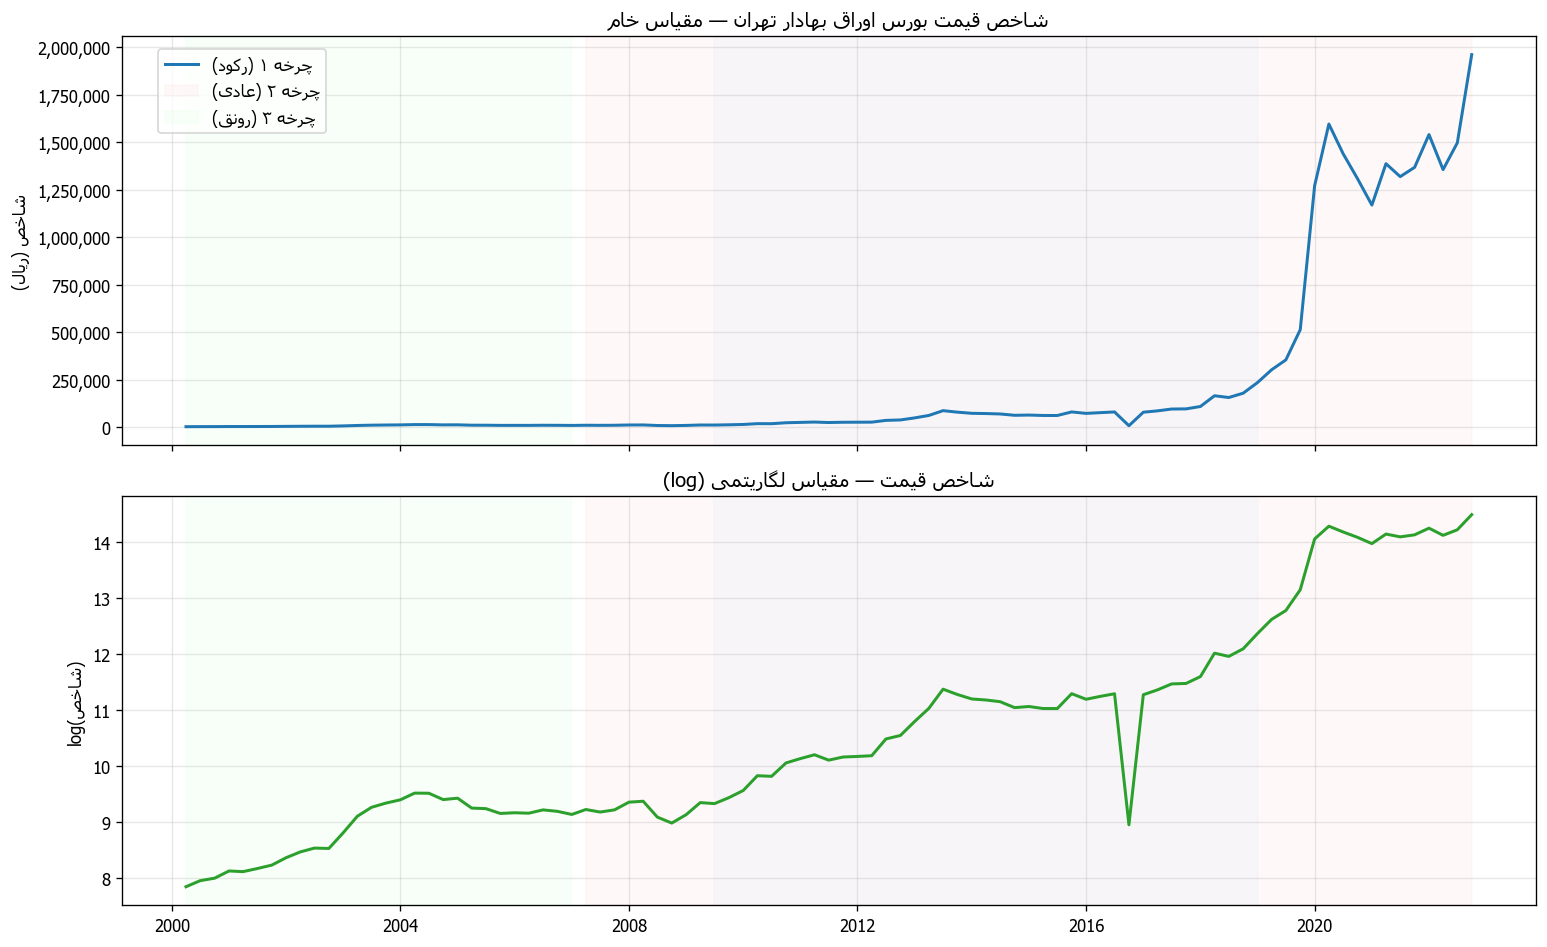

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df.index.to_timestamp(), df["stock_price"],
             color="#1f77b4", linewidth=1.8)
axes[0].set_title(fp("شاخص قیمت بورس اوراق بهادار تهران — مقیاس خام"), fontsize=12)
axes[0].set_ylabel(fp("شاخص (ریال)"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].plot(df.index.to_timestamp(), df["log_stock_price"],
             color="#2ca02c", linewidth=1.8)
axes[1].set_title(fp("شاخص قیمت — مقیاس لگاریتمی (log)"), fontsize=12)
axes[1].set_ylabel(fp("log(شاخص)"))

for ax in axes:
    ylim = ax.get_ylim()
    for period_val, color in [(1, "#ffcccc"), (2, "#ccffcc"), (3, "#cce5ff")]:
        mask = df["cycle"] == period_val
        if mask.any():
            dates_ts = df.index[mask].to_timestamp()
            ax.fill_between(dates_ts, ylim[0], ylim[1],
                            alpha=0.12, color=color)
    ax.set_ylim(ylim)

fig.legend(
    [fp("چرخه ۱ (رکود)"), fp("چرخه ۲ (عادی)"), fp("چرخه ۳ (رونق)")],
    loc="upper left", bbox_to_anchor=(0.1, 0.95)
)

plt.tight_layout()
os.makedirs(os.path.join("..", "results", "figures"), exist_ok=True)
plt.savefig(os.path.join("..", "results", "figures", "00_stock_price_history.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### ۹-۲. بازده لگاریتمی (log_return)

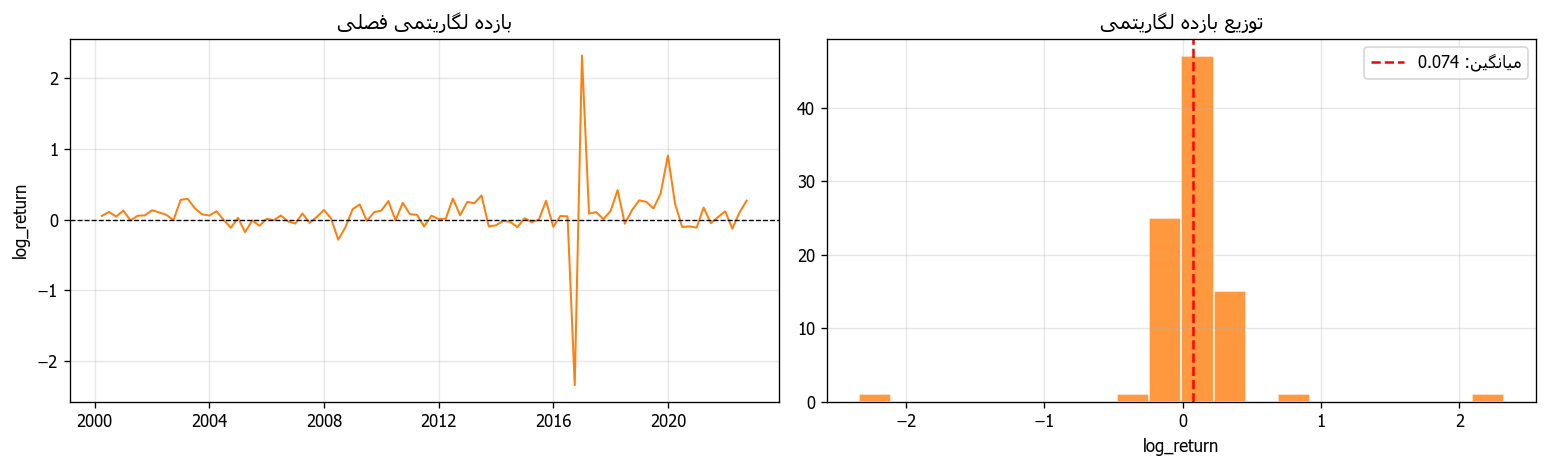

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(df.index.to_timestamp(), df["log_return"],
             color="#ff7f0e", linewidth=1.2)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title(fp("بازده لگاریتمی فصلی"))
axes[0].set_ylabel(fp("log_return"))

axes[1].hist(df["log_return"], bins=20,
             color="#ff7f0e", edgecolor="white", alpha=0.8)
axes[1].axvline(df["log_return"].mean(), color="red", linestyle="--",
                label=fp(f"میانگین: {df['log_return'].mean():.3f}"))
axes[1].set_title(fp("توزیع بازده لگاریتمی"))
axes[1].set_xlabel(fp("log_return"))
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join("..", "results", "figures", "00_log_return.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### ۹-۳. ماتریس همبستگی متغیرهای ورودی

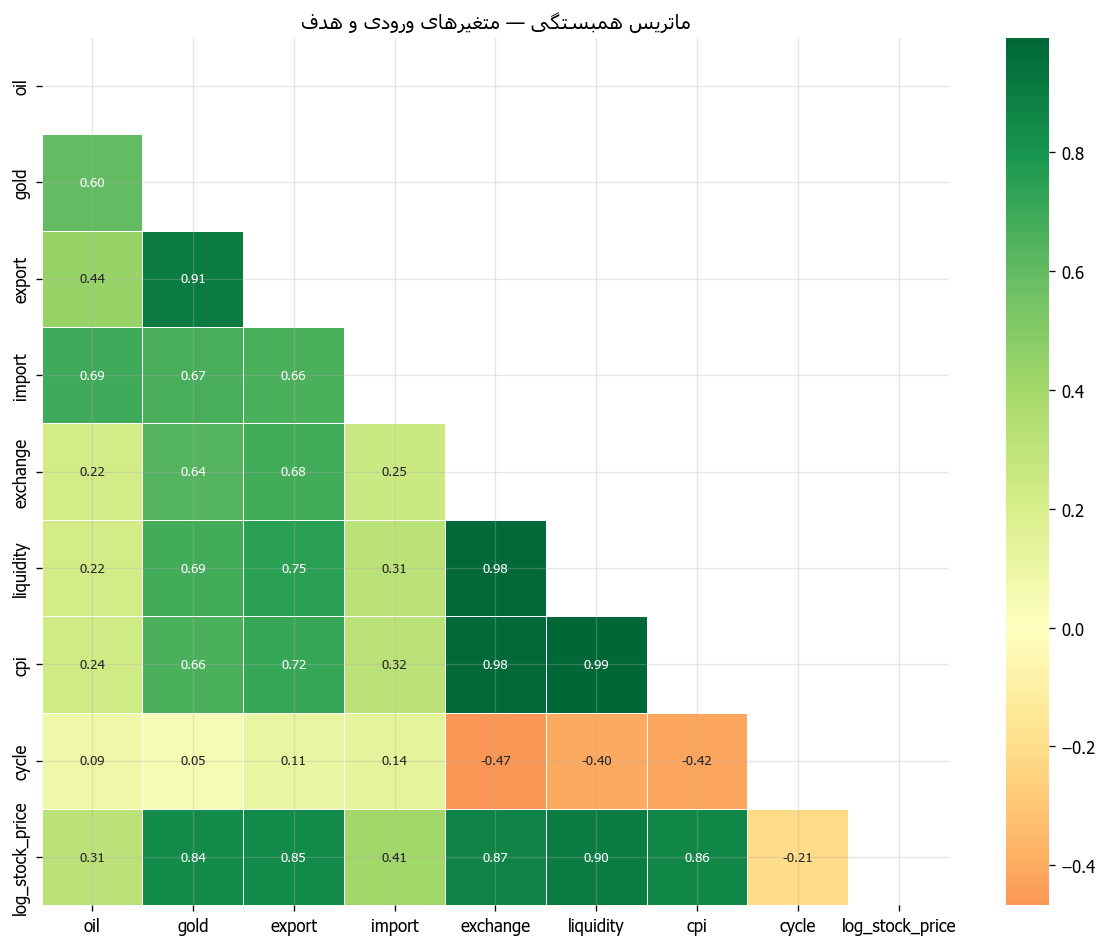


ﺖﺳﺍ multicollinearity ﻩﺪﻨﻫﺩﻥﺎﺸﻧ ﺯﺭﺍ ﺥﺮﻧ ﻭ ﻡﺭﻮﺗ ،ﯽﮕﻨﯾﺪﻘﻧ ﻦﯿﺑ ﻻﺎﺑ ﯽﮕﺘﺴﺒﻤﻫ :ﻪﺘﮑﻧ 📌


In [21]:
feature_cols = ["oil", "gold", "export", "import",
                "exchange", "liquidity", "cpi", "cycle"]
corr = df[feature_cols + ["log_stock_price"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title(fp("ماتریس همبستگی — متغیرهای ورودی و هدف"), fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "figures", "00_correlation_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(fp("\n📌 نکته: همبستگی بالا بین نقدینگی، تورم و نرخ ارز نشان‌دهنده multicollinearity است"))

### ۹-۴. رابطه هر متغیر ورودی با log_stock_price

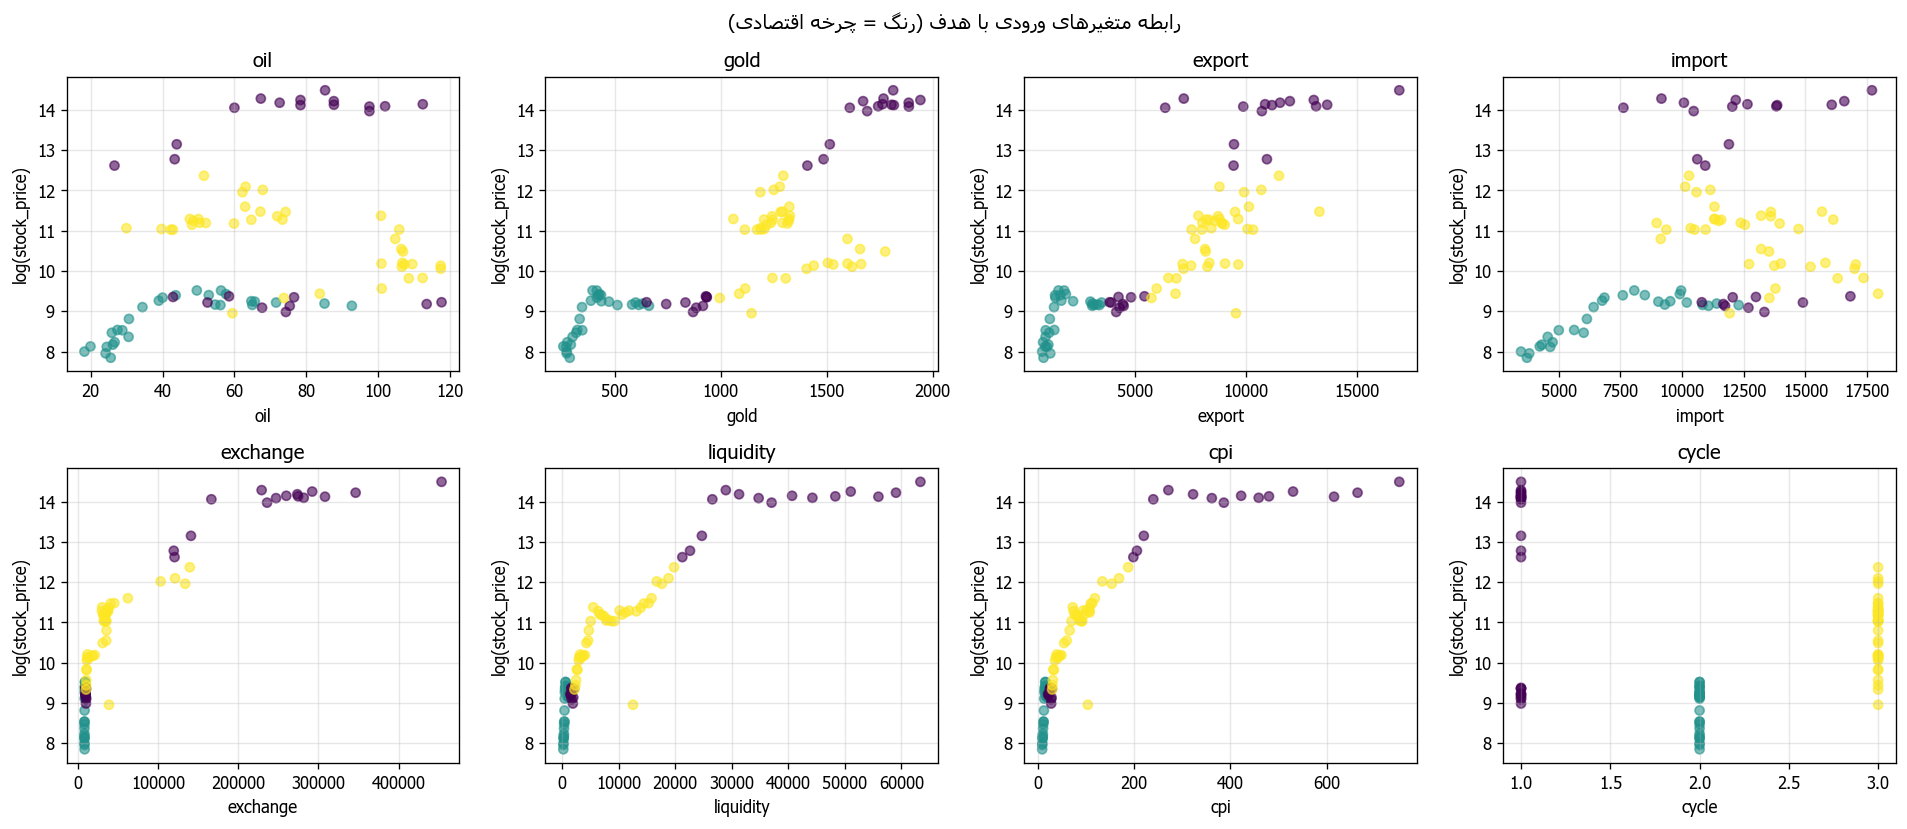

In [22]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df["log_stock_price"],
                    c=df["cycle"], cmap="viridis", alpha=0.6, s=30)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(fp("log(stock_price)"))
    axes[i].set_title(col)

plt.suptitle(fp("رابطه متغیرهای ورودی با هدف (رنگ = چرخه اقتصادی)"), fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "figures", "00_feature_vs_target.png"),
            dpi=150, bbox_inches="tight")
plt.show()

### ۹-۵. توزیع چرخه اقتصادی

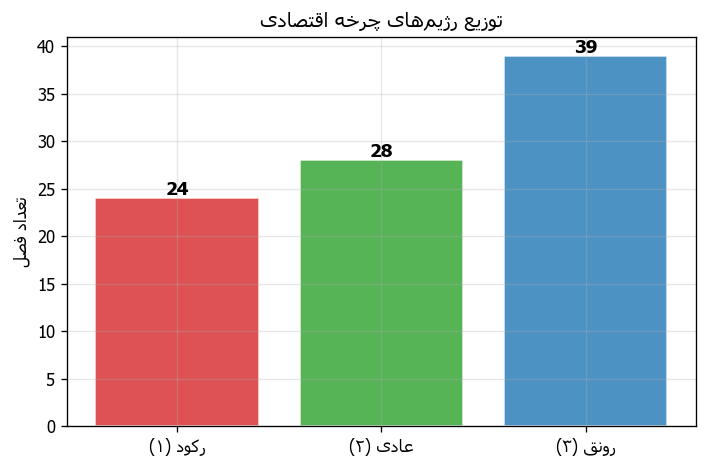

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
cycle_counts = df["cycle"].value_counts().sort_index()
cycle_labels = {
    1: fp("رکود (۱)"),
    2: fp("عادی (۲)"),
    3: fp("رونق (۳)")
}
bars = ax.bar(
    [cycle_labels[c] for c in cycle_counts.index],
    cycle_counts.values,
    color=["#d62728", "#2ca02c", "#1f77b4"],
    alpha=0.8, edgecolor="white"
)
for bar, val in zip(bars, cycle_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", fontsize=11, fontweight="bold")
ax.set_title(fp("توزیع رژیم‌های چرخه اقتصادی"))
ax.set_ylabel(fp("تعداد فصل"))
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "figures", "00_cycle_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## ۱۰. تقسیم داده به آموزش و آزمون

**اصل مهم:** برای داده سری زمانی، تقسیم باید **کاملاً زمانی (chronological)** باشد.
هیچ‌گاه نباید از `train_test_split` با `shuffle=True` استفاده کرد،
زیرا داده آینده را در آموزش قرار می‌دهد و نتایج را دچار **data leakage** می‌کند.

**تقسیم انتخاب‌شده:**
- آموزش: ۱۳۷۹Q1 تا ۱۳۹۷Q4 (۷۵ مشاهده ≈ ۱۹ سال)
- آزمون: ۱۳۹۸Q1 تا ۱۴۰۱Q4 (۱۶ مشاهده = ۴ سال)

In [24]:
TEST_QUARTERS = 16

train = df.iloc[:-TEST_QUARTERS].copy()
test  = df.iloc[-TEST_QUARTERS:].copy()

print(f"آموزش: {train.index[0]}  →  {train.index[-1]}  ({len(train)} مشاهده)")
print(f"آزمون: {test.index[0]}  →  {test.index[-1]}  ({len(test)} مشاهده)")
print(f"\nنسبت آزمون: {len(test)/(len(train)+len(test))*100:.1f}%")

آموزش: 2000Q2  →  2018Q4  (75 مشاهده)
آزمون: 2019Q1  →  2022Q4  (16 مشاهده)

نسبت آزمون: 17.6%


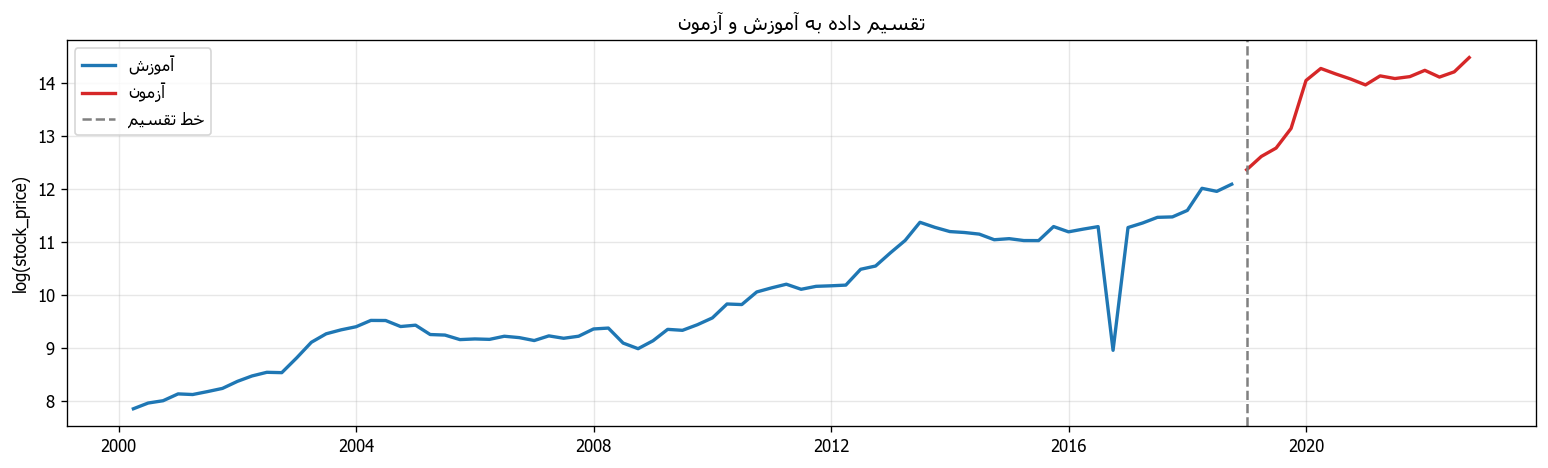

In [25]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index.to_timestamp(), train["log_stock_price"],
        color="#1f77b4", linewidth=2, label=fp("آموزش"))
ax.plot(test.index.to_timestamp(), test["log_stock_price"],
        color="#d62728", linewidth=2, label=fp("آزمون"))
ax.axvline(test.index[0].to_timestamp(), color="gray",
           linestyle="--", linewidth=1.5, label=fp("خط تقسیم"))
ax.set_title(fp("تقسیم داده به آموزش و آزمون"))
ax.set_ylabel(fp("log(stock_price)"))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "figures", "00_train_test_split.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## ۱۱. ذخیره داده‌های پردازش‌شده

سه فایل ذخیره می‌شود که notebook‌های بعدی از آن‌ها استفاده خواهند کرد:
- `master_data.csv` — کل داده پردازش‌شده
- `train_data.csv` — داده آموزش
- `test_data.csv` — داده آزمون

In [26]:
OUT_DIR = os.path.join("..", "data", "processed")
os.makedirs(OUT_DIR, exist_ok=True)

df.to_csv(os.path.join(OUT_DIR, "master_data.csv"))
train.to_csv(os.path.join(OUT_DIR, "train_data.csv"))
test.to_csv(os.path.join(OUT_DIR, "test_data.csv"))

print("✓ داده‌ها ذخیره شدند:")
print(f"  master_data.csv  : {len(df)} ردیف × {len(df.columns)} ستون")
print(f"  train_data.csv   : {len(train)} ردیف")
print(f"  test_data.csv    : {len(test)} ردیف")
print()
print("ستون‌های موجود در داده پردازش‌شده:")
print(list(df.columns))

✓ داده‌ها ذخیره شدند:
  master_data.csv  : 91 ردیف × 19 ستون
  train_data.csv   : 75 ردیف
  test_data.csv    : 16 ردیف

ستون‌های موجود در داده پردازش‌شده:
['period_persian', 'stock_price', 'oil', 'gold', 'export', 'import', 'exchange', 'liquidity', 'cpi', 'cycle', 'oil_x_cycle', 'gold_x_cycle', 'export_x_cycle', 'import_x_cycle', 'exchange_x_cycle', 'liquidity_x_cycle', 'cpi_x_cycle', 'log_stock_price', 'log_return']


## ✅ خلاصه این Notebook

| مرحله | خروجی |
|-------|-------|
| ادغام ۷ شیت | DataFrame با ۱۸ ستون |
| پاکسازی نام‌ها | ستون‌های استاندارد انگلیسی |
| تبدیل تاریخ | PeriodIndex فصلی |
| تبدیل لگاریتمی | `log_stock_price`، `log_return` |
| EDA | ۵ نمودار در `results/figures/` |
| تقسیم داده | آموزش ۷۵ + آزمون ۱۶ مشاهده |
| ذخیره | ۳ فایل CSV در `data/processed/` |

**مرحله بعدی:** `01_xgboost.ipynb`